# 00 - Adversarial Patch Generation

This notebook generates the high-impact $100 \times 100$ adversarial patch used to fool the ResNet50 classifier.
To ensure the patch survives resizing, interpolation, and center-cropping during the dataset generation pipeline, we optimize it directly over real background images from our dataset with random placement and scaling.

**Target Class:** 340 (Zebra) - Chosen for its dominant, high-frequency spatial features.

In [9]:
import torch
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
from PIL import Image
import os
import glob
import random
import subprocess
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using compute device: {device}")

# Load Pretrained ResNet50
model = resnet50(weights=ResNet50_Weights.DEFAULT).to(device).eval()

# We target class 340 (Zebra)
target_class = torch.tensor([340], device=device)

Using compute device: cuda


In [10]:
# Load backgrounds from the dataset so the patch learns to overpower real image features
base_dir = "../data/imagenette2-320/val"
image_paths = glob.glob(os.path.join(base_dir, "**", "*.JPEG"), recursive=True) + \
              glob.glob(os.path.join(base_dir, "**", "*.png"), recursive=True)

# Prompt for download if missing
if not image_paths:
    print(f"WARNING: No images found in {base_dir}.")
    user_input = input("Would you like to download the dataset by running download.py? (y/n): ")

    if user_input.strip().lower() in ['y', 'yes']:
        print("Running download.py (this might take a moment)...")
        try:
            subprocess.run(["python", "../src/data/download.py"], check=True)
            print("Download complete!")

            image_paths = glob.glob(os.path.join(base_dir, "**", "*.JPEG"), recursive=True) + \
                          glob.glob(os.path.join(base_dir, "**", "*.png"), recursive=True)
            if not image_paths:
                print("Dataset still not found after download. The patch will optimize over random noise.")
        except subprocess.CalledProcessError:
            print("Error occurred while running download.py. The patch will optimize over random noise.")
    else:
        print("Download skipped. The patch will optimize over random noise.")
def get_real_backgrounds(batch_size):
    if image_paths:
        batch = []
        for _ in range(batch_size):
            img_path = random.choice(image_paths)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((224, 224))
                batch.append(T.ToTensor()(img))
            except:
                batch.append(torch.rand((3, 224, 224)))
        return torch.stack(batch).to(device)
    else:
        return torch.rand((batch_size, 3, 224, 224), device=device)

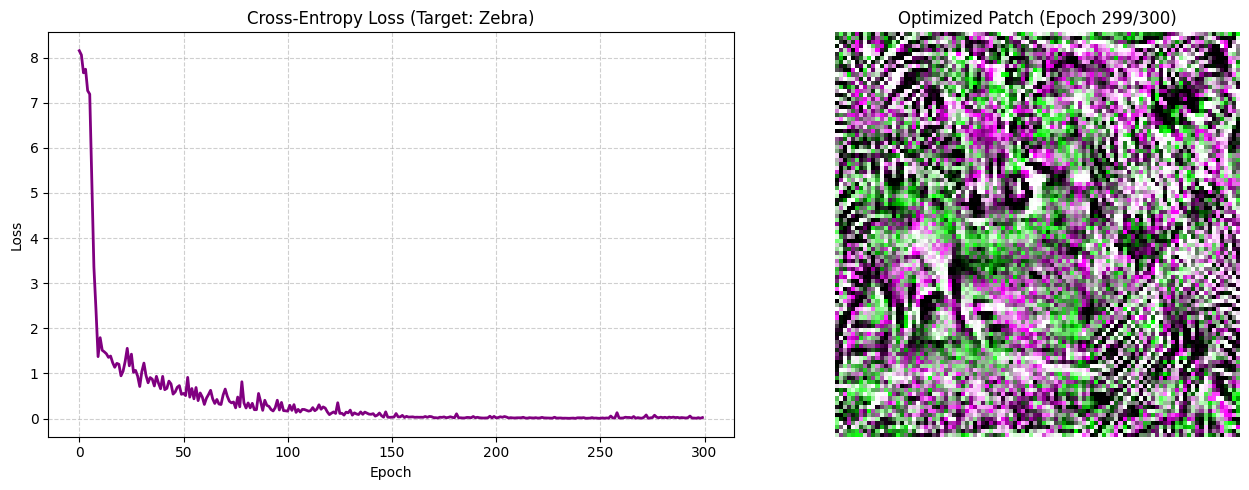

Optimization Complete!


In [11]:
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from IPython.display import clear_output
import matplotlib.pyplot as plt

# TRAP FIX: We use R=B Symmetry to prevent OpenCV from destroying the patch
# when it swaps BGR to RGB during dataset generation.
patch_base = torch.rand((1, 2, 100, 100), device=device, requires_grad=True)

# AdamW with a higher learning rate and weight decay
optimizer = torch.optim.AdamW([patch_base], lr=0.08, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss()
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

epochs = 300
batch_size = 16
losses = []

print("Starting optimization...")

for i in range(epochs):
    optimizer.zero_grad()
    
    # Build the 3-channel patch where R == B (Channel 0 copied to 0 and 2, Channel 1 to 1)
    patch_rgb = torch.cat([patch_base[:, 0:1], patch_base[:, 1:2], patch_base[:, 0:1]], dim=1)

    bg = get_real_backgrounds(batch_size)
    img = bg.clone()
    target_batch = target_class.expand(batch_size)

    for b in range(batch_size):
        # Safe-zone placement (inner 70% of the image)
        h, w = 224, 224
        ph, pw = 100, 100
        margin_y, margin_x = int(h * 0.15), int(w * 0.15)

        min_y, max_y = margin_y, h - ph - margin_y
        min_x, max_x = margin_x, w - pw - margin_x

        start_y = torch.randint(min_y, max_y + 1, (1,)).item()
        start_x = torch.randint(min_x, max_x + 1, (1,)).item()

        img[b, :, start_y:start_y+ph, start_x:start_x+pw] = patch_rgb[0]

    # Add small noise to simulate dataset compression
    img = img + torch.randn_like(img) * 0.05
    img = torch.clamp(img, 0, 1)

    img_norm = normalize(img)
    outputs = model(img_norm)

    loss = criterion(outputs, target_batch)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        patch_base.clamp_(0, 1)

    losses.append(loss.item())

    # --- Live Visualization Block ---
    if i % 10 == 0 or i == epochs - 1:
        clear_output(wait=True)
        # Re-construct patch for display
        display_patch = torch.cat([patch_base[:, 0:1], patch_base[:, 1:2], patch_base[:, 0:1]], dim=1)
        patch_np = display_patch.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        ax1.plot(losses, color='purple', linewidth=2)
        ax1.set_title("Cross-Entropy Loss (Target: Zebra)")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Loss")
        ax1.grid(True, linestyle='--', alpha=0.6)

        ax2.imshow(patch_np)
        ax2.set_title(f"Optimized Patch (Epoch {i}/{epochs})")
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

print("Optimization Complete!")


In [12]:
# Save out the resulting image to be used by the pipeline
os.makedirs('../data', exist_ok=True)
final_patch_np = patch.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
final_patch_img = (final_patch_np * 255).astype(np.uint8)

save_path = '../data/adversarial_patch.png'
Image.fromarray(final_patch_img).save(save_path)

print(f"High-Impact 100x100 patch successfully saved to: {save_path}")

import sys
sys.path.insert(0, "..")
user_input_gen = input("Would you like to generate the dataset? (y/n): ")
if user_input_gen.strip().lower() in ['y', 'yes']:
    print("generating dataset...")
    !python -m src.data.generate ../data/imagenette2-320/val --out ../data/generated --n 100 --patch=../data/adversarial_patch.png --patch-size=100
else:
    print("dataset generation skipped...")

High-Impact 100x100 patch successfully saved to: ../data/adversarial_patch.png
generating dataset...
Wrote 100 triples to ..\data\generated
